## 3.1 Linear Basis Function Models

The linear basis function model has the form as:
\begin{align*}
  y(\mathbf{x}, \mathbf{w}) = \sum_{j=0}^{M-1} w_j \phi_j(\mathbf{x}) = \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x})
\end{align*}
where $\phi_j(\mathbf{x})$ are the basis functions. The basis functions can be nonlinear functions of the input vector $\mathbf{x}$, but the model is linear in the parameters $w_j$.

# 3.1.1 Maximum Likelihood and Least Squares

Assume that the target variable $t$ is generated from the model with additive Gaussian noise:
\begin{align*}
  &t = y(\mathbf{x}, \mathbf{w}) + \epsilon\\
  p(t | \mathbf{x}, \mathbf{w}, \beta) = \mathcal{N}(t | y(\mathbf{x}, \mathbf{w}), \beta^{-1})
\end{align*}
where $\epsilon \sim \mathcal{N}(0, \beta^{-1})$. If we assume the squared loss function, the optimal prediction given by the conditional mean of the predictive distribution:
\begin{align*}
  \hat{t} = \mathbb{E}[t | \mathbf{x}] = y(\mathbf{x}, \mathbf{w})
\end{align*}

The maximum likelihood function:
\begin{align*}
  p(\mathbf{t} | \mathbf{X}, \mathbf{w}, \beta) = \prod_{n=1}^N \mathcal{N}(t_n | y(\mathbf{x}_n, \mathbf{w}), \beta^{-1})
\end{align*}
The log-likelihood function:
\begin{align*}
  \ln p(\mathbf{t} | \mathbf{X}, \mathbf{w}, \beta) &= -\frac{\beta}{2} \sum_{n=1}^N (y(\mathbf{x}_n, \mathbf{w}) - t_n)^2 + \frac{N}{2} \ln \beta - \frac{N}{2} \ln (2\pi)\\
  &= -\frac{\beta}{2} \sum_{n=1}^N (\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n) - t_n)^2 + \frac{N}{2} \ln \beta - \frac{N}{2} \ln (2\pi)
\end{align*}  

Maximizing the log-likelihood is equivalent to minimizing the sum-of-squares error function and the MLE for $\mathbf{w}$ is:
\begin{align*}
  \mathbf{w}_{\text{ML}} = (\Phi^T \Phi)^{-1} \Phi^T \mathbf{t}
\end{align*}

where $\Phi$ is the design matrix with elements $\Phi_{nj} = \phi_j(\mathbf{x}_n)$. In details:
\begin{align*}
  \Phi = \begin{bmatrix}
    \phi_0(\mathbf{x}_1) & \phi_1(\mathbf{x}_1) & \cdots & \phi_{M-1}(\mathbf{x}_1)\\
    \phi_0(\mathbf{x}_2) & \phi_1(\mathbf{x}_2) & \cdots & \phi_{M-1}(\mathbf{x}_2)\\
    \vdots & \vdots & \ddots & \vdots\\
    \phi_0(\mathbf{x}_N) & \phi_1(\mathbf{x}_N) & \cdots & \phi_{M-1}(\mathbf{x}_N)
  \end{bmatrix}
\end{align*}

The quantity $\Phi^\dagger = (\Phi^T \Phi)^{-1} \Phi^T$ is called the Moore-Penrose pseudo-inverse of $\Phi$, which is a generalization of the matrix inverse that can be applied to non-square matrices. The pseudo-inverse has the property that $\Phi \Phi^\dagger \Phi = \Phi$ and $\Phi^\dagger \Phi \Phi^\dagger = \Phi^\dagger$.

For $w_0$ only, the MLE is:
\begin{align*}
  w_0 = \frac{1}{N} \sum_{n=1}^N t_n - \sum_{j=1}^{M-1} w_j \frac{1}{N} \sum_{n=1}^N \phi_j(\mathbf{x}_n)
\end{align*}

The MLE for $\beta$ is:
\begin{align*}
  \frac{1}{\beta_{\text{ML}}} = \frac{1}{N} \sum_{n=1}^N (y(\mathbf{x}_n, \mathbf{w}_{\text{ML}}) - t_n)^2
\end{align*}

# 3.1.2 Geometry of Least Squares

If we consider $\mathbf{t}$ and $\mathbf{y} = \Phi \mathbf{w}$ as vectors in an $N$-dimensional space, the least squares solution corresponds to projecting $\mathbf{t}$ onto the subspace spanned by the columns of $\Phi$. The projection of $\mathbf{t}$ onto this subspace is given by:
\begin{align*}
  \mathbf{y} =\Phi (\Phi^T \Phi)^{-1} \Phi^T \mathbf{t} = \Phi \mathbf{w}_{\text{ML}}
\end{align*}

We can derive this by consider the error vector $\mathbf{e} = \mathbf{t} - \mathbf{y} = \mathbf{t} - \Phi \mathbf{w}$, then if $\mathbf{y}$ is the projection of $\mathbf{t}$ onto the subspace spanned by the columns of $\Phi$, then the error vector $\mathbf{e}$ must be orthogonal to this subspace, which means that $\Phi^T \mathbf{e} = 0$. This leads to the normal equations:
\begin{align*}
  \Phi^T \Phi \mathbf{w} = \Phi^T \mathbf{t}
\end{align*}
which can be solved to give the least squares solution.


# 3.1.3 Sequential Learning

The least squares solution can also be found using a sequential learning algorithm, such as the stochastic gradient descent (SGD) algorithm. The update rule for the weights in SGD is given by:
\begin{align*}
  \mathbf{w} \leftarrow \mathbf{w} - \eta \nabla E(\mathbf{w})
\end{align*}
where $\eta$ is the learning rate and $E(\mathbf{w})$ is the error function. For the least squares error function, the updating rule becomes:
\begin{align*}
  \mathbf{w} \leftarrow \mathbf{w} + \eta (t_n - \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n)) \boldsymbol{\phi}(\mathbf{x}_n)
\end{align*}

# 3.1.4 Regularized Least Squares

To prevent overfitting, we can add a regularization term to the error function. The regularized error function is given by:
\begin{align*}
  E_D(\mathbf{w}) + \lambda E_W(\mathbf{w})
\end{align*}
where $E_D(\mathbf{w})$ is the data error term and $E_W(\mathbf{w})$ is the regularization term. We can consider two common types of regularization: L2 regularization (Ridge regression) and L1 regularization (Lasso regression). L2 regularization can be expressed as:
\begin{align*}
  E_W(\mathbf{w}) = \frac{1}{2} \mathbf{w}^T \mathbf{w}
\end{align*}

The solution for Ridge regression is given by:
\begin{align*}
  \mathbf{w} = (\lambda \mathbf{I} + \Phi^T \Phi)^{-1} \Phi^T \mathbf{t}
\end{align*}

A more general form of regularizer:
\begin{align*}
  E_W(\mathbf{w}) = \frac{1}{2} \sum_{j=1}^M |w_j|^q
\end{align*}
where $q$ is a positive integer. When $q=1$, we have Lasso regression, which can lead to sparse solutions where some weights are exactly zero. 

Elastic net regularization is a combination of L1 and L2 regularization, which can be expressed as:
\begin{align*}
  E_W(\mathbf{w}) = \alpha \sum_{j=1}^M |w_j|^q +  \beta \mathbf{w}^T \mathbf{w}
\end{align*}
where $\alpha$ and $\beta$ are hyperparameters that control the strength of the L1 and L2 regularization, respectively. Elastic net can be particularly useful when there are multiple correlated features, as it can select groups of correlated features together.

# 3.1.5 Multiple Outputs

For multiple output regression, we can extend the linear basis function model to handle multiple target variables. The model can be expressed as:
\begin{align*}
  \mathbf{y}(\mathbf{x}, \mathbf{W}) = \mathbf{W}^T \boldsymbol{\phi}(\mathbf{x})
\end{align*}
where $\mathbf{W}$ is a matrix of weights with dimensions $M \times K$, and $K$ is the number of output variables. If we consider the conditional distribution of the target variables given the input:
\begin{align*}
  p(\mathbf{t} | \mathbf{x}, \mathbf{W}, \beta) = \mathcal{N}(\mathbf{t} | \mathbf{W}^T \boldsymbol{\phi}(\mathbf{x}), \beta^{-1} \mathbf{I})
\end{align*}
where $\mathbf{I}$ is the identity matrix. The maximum likelihood solution for $\mathbf{W}$ can be found by minimizing the sum-of-squares error function, which leads to the solution:
\begin{align*}
  \mathbf{W} = (\Phi^T \Phi)^{-1} \Phi^T \mathbf{T}
\end{align*}
where $\mathbf{T}$ is the matrix of target variables with dimensions $N \times K$. If we examine the solution for each output variable separately, we can see that the solution for each output variable is given by:
\begin{align*}
  \mathbf{w}_k = (\Phi^T \Phi)^{-1} \Phi^T \mathbf{t}_k
\end{align*}
where $\mathbf{t}_k$ is the $k$-th column of the target matrix $\mathbf{T}$. This means that the solution for each output variable can be found independently, and the overall solution can be obtained by combining the solutions for each output variable.

# 3.2 The Bias-Variance Decomposition

We have shown that the optimal prediction for a given input $\mathbf{x}$ is given by the conditional mean of the predictive distribution:
\begin{align*}
  h(\mathbf{x}) = \mathbb{E}[t | \mathbf{x}]
\end{align*}
The expected squared loss:
\begin{align*}
  \mathbb{E}[L] = \int (y(\mathbf{x}) - h(\mathbf{x}))^2 p(\mathbf{x}) d\mathbf{x} + \int \{h(\mathbf{x}) - t\}^2 p(\mathbf{x}, t)  d\mathbf{x} dt
\end{align*}
We can decompose the first term into bias and variance:
\begin{align*}
  E_D[{y(\mathbf{x}, D)-h(\mathbf{x})}^2] = \{E_D[y(\mathbf{x}, D)] - h(\mathbf{x})\}^2 + E_D[{y(\mathbf{x}, D) - E_D[y(\mathbf{x}, D)]}^2]
\end{align*}

We obtain the following decomposition of the expected squared loss:
\begin{align*}
  \text{Expected Loss} = \text{Bias}^2 + \text{Variance} + \text{Noise}
\end{align*}
where:
\begin{align*}
  \text{Bias}^2 &= \int \{E_D[y(\mathbf{x}, D)] - h(\mathbf{x})\}^2 p(\mathbf{x}) d\mathbf{x}\\
  \text{Variance} &= \int E_D[{y(\mathbf{x}, D) - E_D[y(\mathbf{x}, D)]}^2] p(\mathbf{x}) d\mathbf{x}\\
  \text{Noise} &= \int \{h(\mathbf{x}) - t\}^2 p(\mathbf{x}, t)  d\mathbf{x} dt
\end{align*}

# 3.3 Bayesian Linear Regression

We introduce a Bayesian treatment linear regression, which will avoid the over-fitting problem of maximum likelihood, and which will also lead to automatic methods of determining model complexity using the training data alone.

# 3.3.1 Parameter Distribution

The likelihood function $p(\mathbf{t} | \mathbf{w})$ is the exponential of a quadratic function of $\mathbf{w}$. The corresponding conjugate prior distribution over $\mathbf{w}$ is a Gaussian distribution:
\begin{align*}
  p(\mathbf{w} ) = \mathcal{N}(\mathbf{w} | \mathbf{m}_0, \mathbf{S}_0)
\end{align*}
where $\mathbf{m}_0$ is the mean and $\mathbf{S}_0$ is the covariance matrix. 

Using (2.116) - Exercise 3.7, the posterior distribution is:
\begin{align*}
  p(\mathbf{w} | \mathbf{t}) = \mathcal{N}(\mathbf{w} | \mathbf{m}_N, \mathbf{S}_N)
\end{align*}
where:
\begin{align*}
  \mathbf{S}_N^{-1} &= \mathbf{S}_0^{-1} + \beta \Phi^T \Phi\\
  \mathbf{m}_N &= \mathbf{S}_N (\mathbf{S}_0^{-1} \mathbf{m}_0 + \beta \Phi^T \mathbf{t})
\end{align*}
If we consider a infinitely broad prior distribution, which corresponds to $\mathbf{S}_0^{-1} \rightarrow 0$, then the posterior distribution becomes:
\begin{align*}
  \mathbf{S}_N^{-1} &= \beta \Phi^T \Phi\\
  \mathbf{m}_N &= \mathbf{S}_N \beta \Phi^T \mathbf{t} = (\Phi^T \Phi)^{-1} \Phi^T \mathbf{t}
\end{align*}
which is the same as the maximum likelihood solution.

For the remainder of the chapter, we consider a zero-mean isotropic Gaussian prior distribution over the parameters:
\begin{align*}
  p(\mathbf{w} | \alpha) = \mathcal{N}(\mathbf{w} | \mathbf{0}, \alpha^{-1} \mathbf{I})
\end{align*}
and the corresponding posterior distribution is given by:
\begin{align*}
  p(\mathbf{w} | \mathbf{t}, \alpha, \beta) = \mathcal{N}(\mathbf{w} | \mathbf{m}_N, \mathbf{S}_N)
\end{align*}
where:
\begin{align*}
  \mathbf{S}_N^{-1} &= \alpha \mathbf{I} + \beta \Phi^T \Phi\\
  \mathbf{m}_N &= \beta \mathbf{S}_N \Phi^T \mathbf{t}
\end{align*}

The log of posterior distribution is given by:

\begin{align*}
  \ln p(\mathbf{w} | \mathbf{t}, \alpha, \beta) &= \ln p(\mathbf{t} | \mathbf{w}, \beta)
  + \ln p(\mathbf{w} | \alpha) - \ln p(\mathbf{t} | \alpha, \beta)\\
  &= -\frac{\beta}{2} \sum_{n=1}^N (\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n) - t_n)^2 - \frac{\alpha}{2} \mathbf{w}^T \mathbf{w} + \text{constant}
\end{align*}

Maximizing this log-posterior is equivalent to minimizing the regularized sum-of-squares error function with $\lambda = \alpha / \beta$.




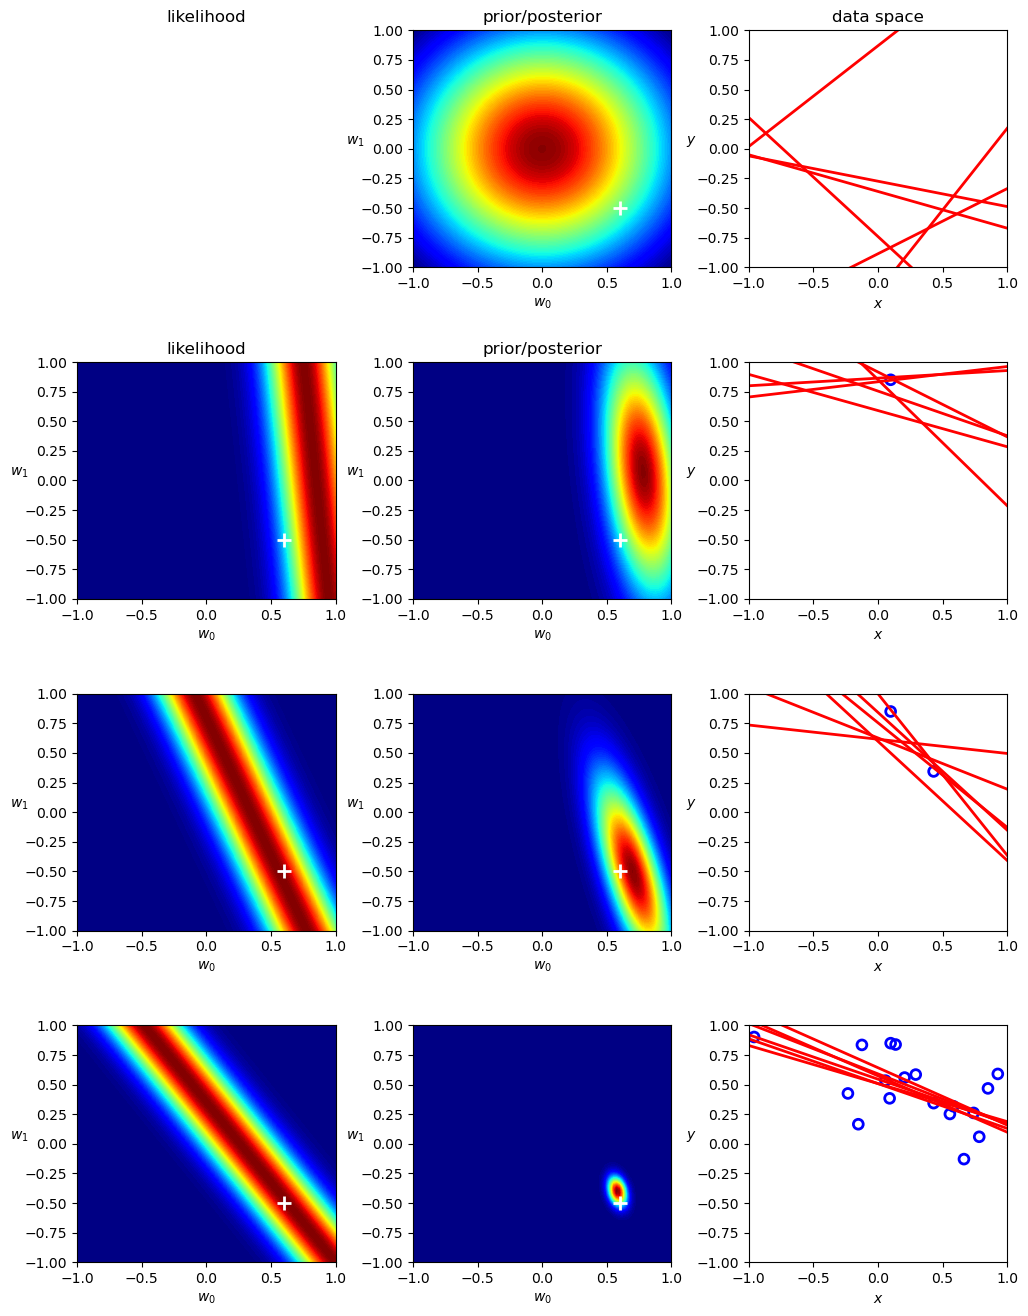

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal


w0_true = 0.6
w1_true = -0.5

alpha = 2.0  
beta = 25.0  

np.random.seed(0) 
N_samples = 20
X_data = np.random.uniform(-1, 1, N_samples)
t_data = w0_true + w1_true * X_data + np.random.normal(0, np.sqrt(1/beta), N_samples)

grid_size = 100
w0_grid, w1_grid = np.meshgrid(np.linspace(-1, 1, grid_size), 
                               np.linspace(-1, 1, grid_size))
w_points = np.c_[w0_grid.ravel(), w1_grid.ravel()]


def calculate_likelihood(x, t, w0, w1, beta):
    """Calculates the likelihood of a single data point over the parameter grid."""
    # p(t | x, w) = N(t | w0 + w1*x, beta^-1)
    return norm.pdf(t, loc=w0 + w1 * x, scale=np.sqrt(1/beta))

def get_posterior(Phi, t, alpha, beta):
    """Calculates posterior mean and covariance given basis functions and data."""
    S_N_inv = alpha * np.eye(Phi.shape[1]) + beta * Phi.T.dot(Phi)
    S_N = np.linalg.inv(S_N_inv)
    m_N = beta * S_N.dot(Phi.T).dot(t)
    return m_N, S_N

def plot_heatmap(ax, Z, title=""):
    """Plots a heatmap in parameter space."""
    ax.contourf(w0_grid, w1_grid, Z, 100, cmap='jet')
    ax.plot(w0_true, w1_true, 'w+', markersize=10, markeredgewidth=2)
    ax.set_xlabel('$w_0$')
    ax.set_ylabel('$w_1$', rotation=0)
    ax.set_title(title)
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])

def plot_data_space(ax, m_N, S_N, X, t, num_samples=6):
    """Draws lines sampled from the current posterior distribution."""
    ax.scatter(X, t, facecolors='none', edgecolors='b', marker='o', s=50, lw=2)
    
    w_samples = np.random.multivariate_normal(m_N.ravel(), S_N, num_samples)
    x_line = np.linspace(-1, 1, 10)
    for w in w_samples:
        y_line = w[0] + w[1] * x_line
        ax.plot(x_line, y_line, 'r-', lw=2)
        
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$', rotation=0)


fig, axes = plt.subplots(4, 3, figsize=(12, 16))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

stages = [0, 1, 2, N_samples]

for i, n in enumerate(stages):
    ax_like = axes[i, 0]
    if n == 0:
        ax_like.axis('off') 
        ax_like.set_title("likelihood")
    else:
        x_n, t_n = X_data[n-1], t_data[n-1]
        Z_like = calculate_likelihood(x_n, t_n, w0_grid, w1_grid, beta)
        plot_heatmap(ax_like, Z_like)
        if i == 1: ax_like.set_title("likelihood")

    ax_post = axes[i, 1]
    if n == 0:
        m_N = np.array([[0.0], [0.0]])
        S_N = (1/alpha) * np.eye(2)
        Z_post = multivariate_normal.pdf(w_points, mean=m_N.ravel(), cov=S_N).reshape(grid_size, grid_size)
        plot_heatmap(ax_post, Z_post)
        ax_post.set_title("prior/posterior")
    else:
        Phi = np.c_[np.ones(n), X_data[:n]] 
        t = t_data[:n].reshape(-1, 1)
        m_N, S_N = get_posterior(Phi, t, alpha, beta)
        Z_post = multivariate_normal.pdf(w_points, mean=m_N.ravel(), cov=S_N).reshape(grid_size, grid_size)
        plot_heatmap(ax_post, Z_post)
        if i == 1: ax_post.set_title("prior/posterior")

    ax_data = axes[i, 2]
    plot_data_space(ax_data, m_N, S_N, X_data[:n], t_data[:n])
    if i == 0: ax_data.set_title("data space")

plt.show()

# 3.3.2 Predictive Distribution

We evaluate the predictive distribution:
\begin{align*}
  p(t | \mathbf{x}, \mathbf{t}, \alpha, \beta) = \int p(t | \mathbf{x}, \mathbf{w}, \beta) p(\mathbf{w} | \mathbf{t}, \alpha, \beta) d\mathbf{w}
\end{align*}
The predictive distribution is a Gaussian distribution:
\begin{align*}
  p(t | \mathbf{x}, \mathbf{t}, \alpha, \beta) = \mathcal{N}(t | \mathbf{m}_N^T \boldsymbol{\phi}(\mathbf{x}), \sigma_N^2(\mathbf{x}))
\end{align*}
where:
\begin{align*}
  \sigma_N^2(\mathbf{x}) = \frac{1}{\beta} + \boldsymbol{\phi}(\mathbf{x})^T \mathbf{S}_N \boldsymbol{\phi}(\mathbf{x})
\end{align*}
The first term $\frac{1}{\beta}$ represents the noise in the data, while the second term $\boldsymbol{\phi}(\mathbf{x})^T \mathbf{S}_N \boldsymbol{\phi}(\mathbf{x})$ represents the uncertainty in the model parameters. It is shown that $\sigma_{N+1}^2(\mathbf{x}) \leq \sigma_N^2(\mathbf{x})$. As $N \to \infty$, the second term goes to zero.

Note that if we use localized basis functions, such as Gaussian basis functions, then the predictive variance will be small in regions of the input space where there are many training data points, and large in regions where there are few training data points. This is undesirable, we can adopt an alternative approach such as Gaussian processes.

If both $\mathbf{w}$ and $\beta$ are unknown, we introduce a conjugate prior distribution $p(\mathbf{w}, \beta)$ is a Gaussian-Gamma distribution. In this case, the predictive distribution is a Student's t-distribution.

# 3.3.3 Equivalent Kernel

The predictive mean can be expressed as a linear combination of the target values:
\begin{align*}
  \mathbf{m}_N^T \boldsymbol{\phi}(\mathbf{x}) = \sum_{n=1}^N k(\mathbf{x}, \mathbf{x}_n) t_n
\end{align*}
where the kernel function $k(\mathbf{x}, \mathbf{x}')$ is given by:
\begin{align*}
  k(\mathbf{x}, \mathbf{x}') = \beta \boldsymbol{\phi}(\mathbf{x})^T \mathbf{S}_N \boldsymbol{\phi}(\mathbf{x}')
\end{align*}
The kernel function $k(\mathbf{x}, \mathbf{x}')$ measures the similarity between two input points $\mathbf{x}$ and $\mathbf{x}'$. The equivalent kernel can be used to understand how the predictions are influenced by the training data points. Further insights can be obtained by considering the covariance of $y(\mathbf{x})$ and $y(\mathbf{x}')$:
\begin{align*}
  \text{cov}[y(\mathbf{x}), y(\mathbf{x}')] = \beta^{-1} k(\mathbf{x}, \mathbf{x}')
\end{align*}

Note that $\sum_{n=1}^N k(\mathbf{x}, \mathbf{x}_n) = 1$, this can be shown by considering the predictive mean of all training data points being $1$.

The equivalent kernel can be expressed as a dot product of two vectors:
\begin{align*}
  k(\mathbf{x}, \mathbf{z}) = \beta \boldsymbol{\phi}(\mathbf{x})^T \mathbf{S}_N \boldsymbol{\phi}(\mathbf{z}) = \beta (\mathbf{S}_N^{1/2} \boldsymbol{\phi}(\mathbf{x}))^T (\mathbf{S}_N^{1/2} \boldsymbol{\phi}(\mathbf{z}))
\end{align*}
This shows that the equivalent kernel can be interpreted as a dot product in a transformed feature space defined by $\mathbf{S}_N^{1/2} \boldsymbol{\phi}(\mathbf{x})$. 

This is similar to the kernel trick used in support vector machines, where the kernel function can be interpreted as a dot product in a high-dimensional feature space. In this case, the equivalent kernel allows us to understand how the predictions are influenced by the training data points in terms of their similarity in the transformed feature space.

# 3.4 Bayesian Model Comparison
Suppose we wish to compare $L$ models $M_1, M_2, \cdots , M_L$. Given traning data $D$, we want to evaluate the posterior probability of each model:
\begin{align*}
  p(M_i | D) \propto p(D | M_i) p(M_i)
\end{align*}

Once we know the posterior probability of each model, we can make predictions by averaging over all models:
\begin{align*}
  p(t | \mathbf{x}, D) = \sum_{i=1}^L p(t | \mathbf{x}, M_i, D) p(M_i | D)
\end{align*}

The model evidence $p(D | M_i)$ is given by:
\begin{align*}
  p(D | M_i) = \int p(D | \mathbf{w}, M_i) p(\mathbf{w} | M_i) d\mathbf{w}
\end{align*}

If we assume the posterior distribution over the parameters is sharply peaked around its most probable value $\mathbf{w}_{\text{MAP}}$ with width $\Delta w_{\text{MAP}}$. Furthermore, we assume that the prior distribution over the parameters is relatively flat with width $\Delta w_{\text{prior}}$. Then we can approximate the model evidence as:
\begin{align*}
  p(D | M_i) \approx p(D | \mathbf{w}_{\text{MAP}}, M_i) \times \frac{\Delta w_{\text{MAP}}}{\Delta w_{\text{prior}}}
\end{align*}

And taking the logarithm of the model evidence gives:
\begin{align*}
  \ln p(D | M_i) \approx \ln p(D | \mathbf{w}_{\text{MAP}}, M_i) + \ln \frac{\Delta w_{\text{MAP}}}{\Delta w_{\text{prior}}}
\end{align*}  

The first term $\ln p(D | \mathbf{w}_{\text{MAP}}, M_i)$ represents the goodness of fit of the model to the data. The second term $\ln \frac{\Delta w_{\text{MAP}}}{\Delta w_{\text{prior}}}$ represents the complexity of the model, which penalizes models with more parameters. If parameters are well tuned to the data, then $\frac{\Delta w_{\text{MAP}}}{\Delta w_{\text{prior}}}$ will be small and the penalty term will be large.

For a model with $M$ parameters, we can make similar approximation to the model evidence:
\begin{align*}
  \ln p(D | M_i) \approx \ln p(D | \mathbf{w}_{\text{MAP}}, M_i) + M \ln \frac{\Delta w_{\text{MAP}}}{\Delta w_{\text{prior}}}
\end{align*}

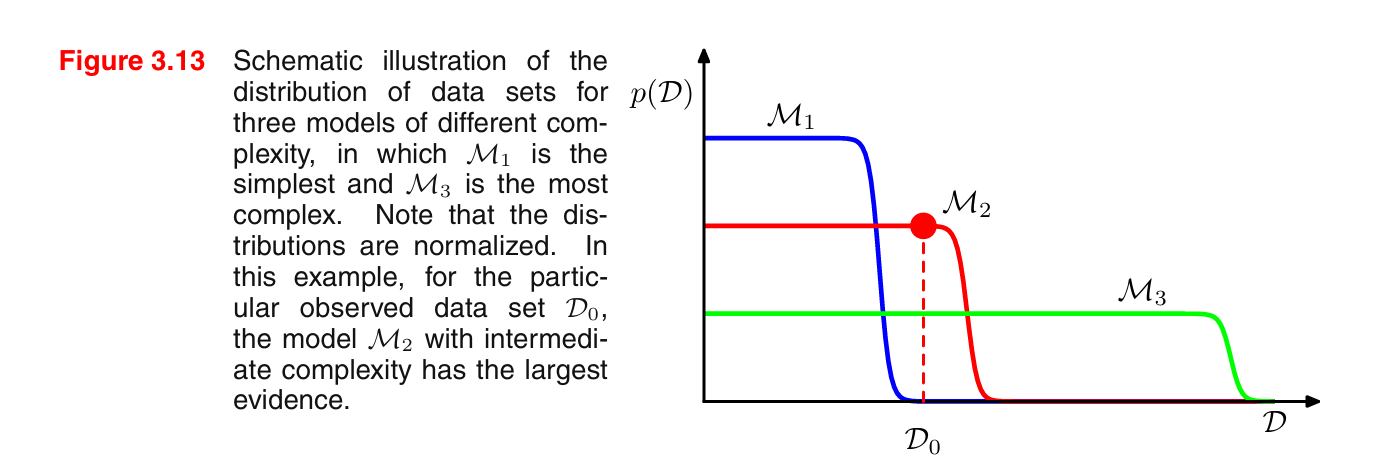

A simple model has little variability so will generate data sets that are fairly similar to each other. A more complex model has more variability so will generate data sets that are more different from each other. 

For a particular data set $D_0$, a simple model may not be able to fit the data well, while a more complex model spread its probability mass over a wider range of data sets, so it may assign a lower probability to $D_0$. 

We consider two models $M_1$ and $M_2$ in which the truth corresponds to $M_1$. If we average the Bayes Factor over the distribution of data sets:
\begin{align*}
  \int p(D | M_1) \ln \frac{p(D | M_1)}{p(D | M_2)} dD
\end{align*}

This is an example of the Kullback-Leibler divergence between the two models, which is always non-negative and is zero if and only if $p(D | M_1) = p(D | M_2)$ for all $D$. This means that on average, the Bayes Factor will favor the true model $M_1$ over the false model $M_2$.

# 3.5 Evidence Approximation

If we introduce hyperpriors over the hyperparameters $\alpha$ and $\beta$, the predictive distribution becomes:
\begin{align*}
  p(t | \mathbf{x}, \mathbf{t}) = \iiint p(t | \mathbf{x}, \mathbf{w}, \beta) p(\mathbf{w} | \mathbf{t}, \alpha, \beta) p(\alpha) p(\beta) d\mathbf{w} d\alpha d\beta
\end{align*}

If the posterior distribution over the hyperparameters is sharply peaked around values $\hat{\alpha}$ and $\hat{\beta}$, then we can approximate the predictive distribution as:
\begin{align*}
  p(t | \mathbf{x}, \mathbf{t}) \approx p(t | \mathbf{x}, \mathbf{t}, \hat{\alpha}, \hat{\beta}) = \int p(t | \mathbf{x}, \mathbf{w}, \hat{\beta}) p(\mathbf{w} | \mathbf{t}, \hat{\alpha}, \hat{\beta}) d\mathbf{w}
\end{align*}

The posterior distribution for $\alpha$ and $\beta$ is given by:
\begin{align*}
  p(\alpha, \beta | \mathbf{t}) \propto p(\mathbf{t} | \alpha, \beta) p(\alpha) p(\beta)
\end{align*}
Then the values of $\hat{\alpha}$ and $\hat{\beta}$ can be found by maximizing the marginal likelihood $p(\mathbf{t} | \alpha, \beta)$.

# 3.5.1 Evaluation of the evidence function

The marginal likelihood can be evaluated by integrating over the parameters $\mathbf{w}$:
\begin{align*}
  p(\mathbf{t} | \alpha, \beta) = \int p(\mathbf{t} | \mathbf{w}, \beta) p(\mathbf{w} | \alpha) d\mathbf{w}
\end{align*}

We can write the evidence function as:
\begin{align*}
  p(\mathbf{t} | \alpha, \beta) = \left(\frac{\beta}{2\pi}\right)^{\frac{N}{2}} \left(\frac{\alpha}{2\pi}\right)^{\frac{M}{2}} \int \exp\{-E(\mathbf{w})\} d\mathbf{w}
\end{align*}
where $M$ is the dimension of the parameter vector $\mathbf{w}$, and $E(\mathbf{w})$ is the error function defined as:
\begin{align*}
  E(\mathbf{w}) &= \beta E_D(\mathbf{w}) + \alpha E_W(\mathbf{w}) \\
  &= \frac{\beta}{2} || \mathbf{t} - \Phi \mathbf{w} ||^2 + \frac{\alpha}{2} \mathbf{w}^T \mathbf{w}
\end{align*}

We can write the log of the marginal likelihood as:
\begin{align*}
  \ln p(\mathbf{t} | \alpha, \beta) &= \frac{M}{2} \ln \alpha + \frac{N}{2} \ln \beta - E(\mathbf{m}_N) - \frac{1}{2} \ln|\mathbf{A}| - \frac{N}{2} \ln (2\pi)
\end{align*}
where $\mathbf{A} = \alpha \mathbf{I} + \beta \Phi^T \Phi$ and $\mathbf{m}_N$ is defined as:
\begin{align*}
  \mathbf{m}_N = \beta \mathbf{A}^{-1} \Phi^T \mathbf{t}
\end{align*}

# 3.5.2 Maximizing the evidence function

Value of $\alpha$ that maximizes the evidence function:
\begin{align*}
  \alpha = \frac{\gamma}{\mathbf{m}_N^T \mathbf{m}_N}
\end{align*}
where $\gamma$ is defined as:
\begin{align*}
  \gamma = \sum_{i=1}^M \frac{\lambda_i}{\alpha + \lambda_i}
\end{align*}
where $\lambda_i$ are the eigenvalues of the matrix $\beta \Phi^T \Phi$. The value of $\beta$ that maximizes the evidence function:
\begin{align*}
  \beta = \frac{N - \gamma}{||\mathbf{t} - \Phi \mathbf{m}_N||^2}
\end{align*}

Value of $\beta$ that maximizes the evidence function:
\begin{align*}
  \beta = \frac{N - \gamma}{||\mathbf{t} - \Phi \mathbf{m}_N||^2}
\end{align*}

If both $\alpha$ and $\beta$ are unknown, we can use an iterative procedure to find the values of $\alpha$ and $\beta$ that maximize the evidence function. We can start with initial values for $\alpha$ and $\beta$, then we can update the values of $\alpha$ and $\beta$ after each update of $\gamma$ and $\mathbf{m}_N$ until convergence.

# 3.5.3 Effective number of parameters

The quantity $\gamma$ can be interpreted as the effective number of parameters in the model. It is shown that $\gamma \leq M$, where $M$ is the total number of parameters in the model. 

If we consider the limit $N >> M$, then $\gamma \approx M$, which means that all parameters are well determined by the data. Then the re-estimations of $\alpha$ and $\beta$ become:
\begin{align*}
  \alpha = \frac{M}{2E_W(\mathbf{m}_N)} \quad \text{and} \quad \beta = \frac{N}{2E_D(\mathbf{m}_N)}
\end{align*}

# 3.6 Limitations of Fixed Basis Functions

The difficulty with fixed basis functions is that we have to choose the form of the basis functions and their parameters before we see the data. This can lead to poor performance if the chosen basis functions are not suitable for the data. As a consequence, the number of basis functions required can grow rapidly with the dimensionality of the input space.

Fortunately, there are two properties of real data sets that we can exploit to help alleviate this problem. First of all, the data vectors {$x_n$} typically lie close to a non linear manifold whose intrinsic dimensionality is smaller than that of the input space as a result of strong correlations between the input variables. 